# CIFAR-100 - EfficientNet-B3 From Scratch

This notebook trains a custom EfficientNet-B3-like classifier on CIFAR-100 using the shared project utilities. The run tests whether scaling the from-scratch EfficientNet family beyond the B0-like baseline gives a meaningful gain on the 100-class dataset.

## Experiment Summary

| Item | Setting |
|------|---------|
| Dataset | CIFAR-100 |
| Input size | 224 x 224 |
| Initialization | From scratch |
| Model | Custom EfficientNet-B3-like network |
| Training | SGD with Nesterov momentum and OneCycleLR stepped per batch |
| Regularization | Label smoothing, MixUp, stochastic depth, SE blocks, dropout |
| Checkpoints | `../checkpoint/efficient_net-b3_v1_100_*` |
| Recorded result | Best validation: 78.39%; test: 77.60% |

## Main Takeaway

The larger B3-like model increases capacity, but the final accuracy remains close to the from-scratch CIFAR-100 ceiling seen in the project. This suggests the limiting factor is the small fine-grained dataset rather than model size alone.

## Imports

Load PyTorch, AMP, optimizer/scheduler components, and the shared project helpers for CIFAR-100 data loading, training, checkpointing, and plotting.

In [17]:
import sys

from ipykernel.kernelapp import kernel_flags
from torch.ao.pruning import scheduler

sys.path.append('../..')

import torch
import torch.nn as nn
import torchvision.models as models
from torch import optim
from torch.amp import GradScaler

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

Select CUDA when it is available and enable cuDNN/TF32 acceleration for faster convolution and matrix multiplication on supported NVIDIA GPUs.

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True   # Tensor Cores for fp32 matmuls
    torch.backends.cudnn.allow_tf32 = True          # Tensor Cores for cudnn convolutions
print(f'Using device: {device}')

Using device: cuda


## Data

Build CIFAR-100 train, validation, and test loaders with `batch_size=128`. Images are resized to `224 x 224` and normalized with ImageNet statistics to keep this run comparable with the other high-resolution CIFAR-100 experiments.

The shared loader keeps an 80/20 split from the official 50,000-image training set and evaluates on the official 10,000-image test set.

In [19]:
batch_size = 128

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=224,
    use_imagenet_stats=True,
)
print(f'Train: {len(trainloader)} | Val: {len(valloader)} | Test: {len(testloader)}')

Train: 313 | Val: 79 | Test: 79


## Model Architecture

Define the EfficientNet-style model from small reusable blocks before instantiating it. The architecture uses squeeze-and-excitation attention, depthwise separable convolutions, MBConv blocks, stochastic depth, and dropout before the CIFAR-100 classifier.

In [20]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block.
    se_ratio=0.25 is applied to the *block input* channels (pre-expansion),
    matching the official EfficientNet paper (Tan et al., 2019).
    """
    def __init__(self, expanded_channels, block_input_channels, se_ratio=0.25):
        super(SEBlock, self).__init__()
        squeezed = max(1, int(block_input_channels * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(expanded_channels, squeezed, bias=True),
            nn.SiLU(),
            nn.Linear(squeezed, expanded_channels, bias=True),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x).view(x.size(0), x.size(1), 1, 1)


### Depthwise Separable Block

Wrap depthwise convolution, batch normalization, SiLU activation, SE attention, and pointwise projection into one reusable block. The SE squeeze width is based on the block input channels, matching the EfficientNet paper.

In [21]:
class DepthwiseSeparableConv(nn.Module):
    """
    Depthwise conv -> BN -> SiLU -> SE -> Pointwise conv -> BN.
    SE ratio is applied to block_input_channels (pre-expansion), per paper.
    """
    def __init__(self, in_channels, out_channels, block_input_channels,
                 kernel_size=3, stride=1, se_ratio=0.25):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Sequential(
            nn.Conv2d(
                in_channels, in_channels,
                kernel_size, stride,
                padding=kernel_size // 2,
                groups=in_channels,
                bias=False
            ),
            nn.BatchNorm2d(in_channels),
            nn.SiLU()
        )

        self.se = SEBlock(in_channels, block_input_channels, se_ratio)

        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.se(x)
        x = self.pointwise(x)
        return x


### MBConv and Stochastic Depth

Define drop-path regularization and the mobile inverted bottleneck block. Residual connections are used only when stride and channel count allow an identity shortcut.

In [22]:
class StochasticDepth(nn.Module):
    """Drop Path (Stochastic Depth) regularization per block."""
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob


class MBConv(nn.Module):
    """
    Mobile Inverted Bottleneck Convolution block.
      t=1  -> MBConv1: no expansion (used in Stage 1 only)
      t=6  -> MBConv6: 6x expansion (used in Stages 2-7)
    Stochastic Depth is applied to the residual branch during training.
    """
    def __init__(self, in_channels, out_channels, stride=1,
                 kernel_size=3, t=6, drop_path_rate=0.0):
        super(MBConv, self).__init__()
        expanded = in_channels * t

        # Expansion phase (identity when t=1, i.e. MBConv1)
        if t > 1:
            self.expansion = nn.Sequential(
                nn.Conv2d(in_channels, expanded, kernel_size=1, bias=False),
                nn.BatchNorm2d(expanded),
                nn.SiLU()
            )
        else:
            self.expansion = nn.Identity()

        self.depthwise = DepthwiseSeparableConv(
            in_channels=expanded,
            out_channels=out_channels,
            block_input_channels=in_channels,  # SE squeezed on pre-expansion channels
            kernel_size=kernel_size,
            stride=stride,
        )

        self.use_residual = (stride == 1 and in_channels == out_channels)
        self.stochastic_depth = StochasticDepth(drop_path_rate)

    def forward(self, x):
        identity = x
        out = self.expansion(x)
        out = self.depthwise(out)
        if self.use_residual:
            out = self.stochastic_depth(out)
            out = out + identity
        return out


### EfficientNet-B3-Like Network

Assemble the B3-like stage schedule with 26 MBConv blocks, wider channels, a 1536-channel head, global pooling, dropout, and a 100-class linear classifier.

In [23]:
class EfficientNet(nn.Module):
    """
    EfficientNet-B0-like architecture, corrected to match the paper:
      - Stage 1 uses MBConv1 (t=1, no expansion channel inflation)
      - SE ratio = 0.25 applied to block input channels (pre-expansion)
      - Stochastic Depth linearly scaled 0.0 -> drop_path_rate across all blocks
      - Head Dropout(p=0.2) before classifier
    """
    def __init__(self, num_classes=100, drop_path_rate=0.2, dropout_rate=0.2):
        super(EfficientNet, self).__init__()

        # Stage config: (num_blocks, in_ch, out_ch, kernel, stride, t)
        stage_cfg = stage_cfg = [
            (2, 40,  24, 3, 1, 1),
            (3, 24,  32, 3, 2, 6),
            (3, 32,  48, 5, 2, 6),
            (5, 48,  96, 3, 2, 6),
            (5, 96, 136, 5, 1, 6),
            (6, 136, 232, 5, 2, 6),
            (2, 232, 384, 3, 1, 6),
        ]

        total_blocks = sum(cfg[0] for cfg in stage_cfg)
        block_idx = 0

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 40, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(40),
            nn.SiLU()
        )

        # Build all stages dynamically
        stages = []
        for (num_blocks, in_ch, out_ch, k, s, t) in stage_cfg:
            layers = []
            for i in range(num_blocks):
                dp_rate = drop_path_rate * block_idx / total_blocks
                layers.append(MBConv(
                    in_channels=in_ch if i == 0 else out_ch,
                    out_channels=out_ch,
                    stride=s if i == 0 else 1,
                    kernel_size=k,
                    t=t,
                    drop_path_rate=dp_rate,
                ))
                block_idx += 1
            stages.append(nn.Sequential(*layers))

        self.stages = nn.Sequential(*stages)

        # Head
        self.head = nn.Sequential(
            nn.Conv2d(384, 1536, kernel_size=1, bias=False),
            nn.BatchNorm2d(1536),
            nn.SiLU()
        )

        # Pooling + Dropout + Classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(1536, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        x = self.head(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x


### Model Summary

Instantiate the model on the selected device and print the architecture plus parameter count before configuring the actual training run.

In [24]:
model = EfficientNet().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

EfficientNet(
  (stem): Sequential(
    (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
  )
  (stages): Sequential(
    (0): Sequential(
      (0): MBConv(
        (expansion): Identity()
        (depthwise): DepthwiseSeparableConv(
          (depthwise): Sequential(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU()
          )
          (se): SEBlock(
            (se): Sequential(
              (0): AdaptiveAvgPool2d(output_size=1)
              (1): Flatten(start_dim=1, end_dim=-1)
              (2): Linear(in_features=40, out_features=10, bias=True)
              (3): SiLU()
              (4): Linear(in_features=10, out_features=40, bias=True)
              (5): Sigmoid()


## Training Configuration

Re-initialize the model for the recorded run, then configure the loss, AMP scaler, SGD optimizer, OneCycleLR schedule, and best/last checkpoint paths.

In [25]:
# ── LR Tuning: OneCycleLR ────────────────────────────────────────────────
# Problem: CosineAnnealingLR decays LR monotonically → val loss plateaus
#          when LR becomes very small, the model stops improving.
# Fix: OneCycleLR uses a single aggressive cycle:
#   Phase 1 (pct_start): LR warms up from max_lr/div_factor → max_lr
#   Phase 2: LR anneals from max_lr → max_lr / final_div_factor (cosine)
# Benefits: stronger regularisation via LR annealing, avoids plateau.
#
EPOCHS = 120
STEPS_PER_EPOCH = len(trainloader)  # 625 batches

model = EfficientNet().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = GradScaler('cuda')

optimizer = optim.SGD(
    model.parameters(),
    lr=0.05,          # will be overridden by OneCycleLR
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,              # peak LR (2× previous starting LR)
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    pct_start=0.10,           # 10% warmup
    anneal_strategy='cos',
    div_factor=10.0,         # initial_lr = max_lr / 10  = 0.01
    final_div_factor=1e4,    # min_lr    = initial_lr / 1e4 = 1e-6
)

# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120, eta_min=1e-5)

MODEL_NAME = 'efficient_net-b3_v1_100'
checkpoint = ModelCheckpoint(
    model,
    checkpoint_path=f'../../checkpoint/{MODEL_NAME}_last.pth',
    best_model_path=f'../../checkpoint/{MODEL_NAME}_best.pth',
    mode='max',
    verbose=True,
)

## Training

Run the shared `fit` loop for 120 epochs. MixUp and label smoothing add regularization, and `step_scheduler_per_batch=True` is required because `OneCycleLR` expects one scheduler step per batch.

In [26]:
train_losses, val_losses, val_accs = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device,
    EPOCHS, checkpoint,
    mixup_alpha=0.2,              # mild MixUp for extra regularization
    step_scheduler_per_batch=True, # OneCycleLR steps every batch
    log=True,
)

[RunLogger] Logging to 'logs/2357617671/'  —  run: 'efficientnet_20260526_102446'
[ModelCheckpoint] New best (max): 7.9600 — saved to ..\checkpoint\efficient_net-b3_v1_100_best.pth
Epoch [ 1/120]  Train Loss: 4.4704  Val Loss: 4.0770  Val Acc: 7.96%  LR: 0.011534  Time: 98.88s
[ModelCheckpoint] New best (max): 13.0700 — saved to ..\checkpoint\efficient_net-b3_v1_100_best.pth
Epoch [ 2/120]  Train Loss: 4.2068  Val Loss: 3.8257  Val Acc: 13.07%  LR: 0.016032  Time: 52.20s
[ModelCheckpoint] New best (max): 21.0700 — saved to ..\checkpoint\efficient_net-b3_v1_100_best.pth
Epoch [ 3/120]  Train Loss: 4.0049  Val Loss: 3.4899  Val Acc: 21.07%  LR: 0.023187  Time: 51.65s
[ModelCheckpoint] New best (max): 27.7600 — saved to ..\checkpoint\efficient_net-b3_v1_100_best.pth
Epoch [ 4/120]  Train Loss: 3.7991  Val Loss: 3.1871  Val Acc: 27.76%  LR: 0.032511  Time: 56.92s
[ModelCheckpoint] New best (max): 34.3700 — saved to ..\checkpoint\efficient_net-b3_v1_100_best.pth
Epoch [ 5/120]  Train Loss: 

## Learning Curves

Plot training loss, validation loss, and validation accuracy to inspect convergence and check for overfitting.

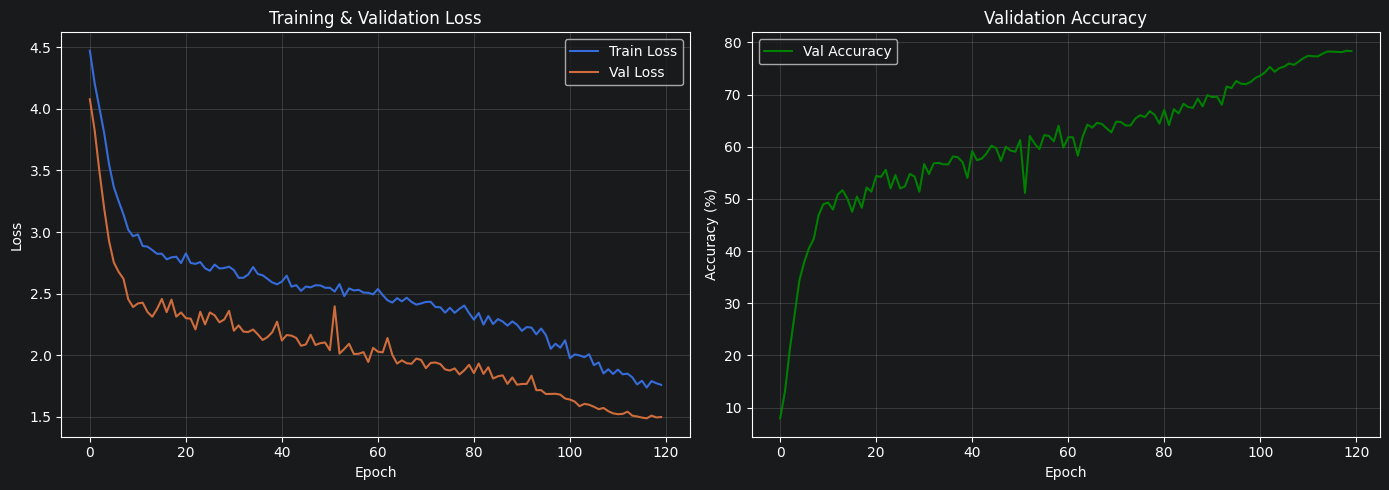

In [27]:
plot_training_curves(train_losses, val_losses, val_accs)

## Test Evaluation

Restore the best validation checkpoint, evaluate on the official CIFAR-100 test split, and print per-class accuracy sorted from strongest to weakest.

In [28]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'Test Accuracy: {overall_acc:.2f}%\n')

print('Per-class accuracies (best first):')
sorted_classes = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
for cls, acc in sorted_classes:
    bar = '█' * int(acc / 5)
    print(f'  {cls:<20s} {acc:5.1f}%  {bar}')

[ModelCheckpoint] Restored best weights from ..\checkpoint\efficient_net-b3_v1_100_best.pth (score=78.3900)
Test Accuracy: 77.60%

Per-class accuracies (best first):
  road                  98.0%  ███████████████████
  orange                97.0%  ███████████████████
  motorcycle            96.0%  ███████████████████
  apple                 94.0%  ██████████████████
  bicycle               94.0%  ██████████████████
  pickup_truck          94.0%  ██████████████████
  sunflower             94.0%  ██████████████████
  palm_tree             93.0%  ██████████████████
  skunk                 93.0%  ██████████████████
  wardrobe              93.0%  ██████████████████
  aquarium_fish         92.0%  ██████████████████
  keyboard              92.0%  ██████████████████
  skyscraper            92.0%  ██████████████████
  tractor               92.0%  ██████████████████
  chimpanzee            91.0%  ██████████████████
  bottle                90.0%  ██████████████████
  chair                 90.0%  